In [217]:
import os

import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
import astropy.constants as cst

from config.units import Gauss
from config.plotting import set_plotting_defaults, Tab20, royalblue_palette, orangered_palette, save_figure
from config.settings import PROPAGATION_DIR

In [218]:
data = np.loadtxt(os.path.join(PROPAGATION_DIR, 'parallel_diffusion.txt'), skiprows=1, unpack=True)
e = data[0] * u.eV
etas = np.array([0.1, 0.5, 1.0, 2.0, 4.0, np.inf])

data2 = np.loadtxt(os.path.join(PROPAGATION_DIR, 'perpendicular_diffusion.txt'), skiprows=1, unpack=True)

# these two files have the very same energy axis
d_prl = data[1:] * u.cm ** 2 / u.s
d_perp = data2[1:] * u.cm**2 / u.s

In [219]:
def dif_cof(l_coh, bfield_ratio, r_g, s=5 / 3):
    l0 = l_coh / np.pi
    R = r_g / l0
    return (1 / 3 * cst.c * (3 * l0 / (16 * np.pi * 0.1188)) * bfield_ratio**(-2) * R**(2 - s) * (2 / ((1 - s/2) * (2 - s/2)) + R**s)).to(u.cm ** 2 / u.s)

In [220]:
def gyration_radius(e, bfield1):
    return (1 * u.pc * (e / u.PeV) * (1e-6 * Gauss / bfield)).to(u.pc)

In [221]:
e_line = np.logspace(9, 20, 100) * u.eV
bfield = 1e-6 * Gauss

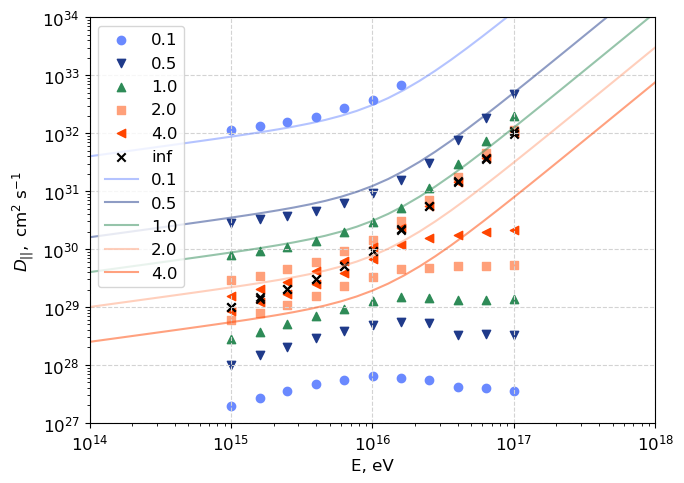

In [222]:
set_plotting_defaults()

colors = [royalblue_palette[0], royalblue_palette[2], 'seagreen',
          orangered_palette[0], orangered_palette[1], 'black']
markers = ['o', 'v', '^', 's', '<', 'x']

for i in range(6):
    plt.scatter(e, d_prl[i], color=colors[i], marker=markers[i], label=etas[i])
    plt.scatter(e, d_perp[i], color=colors[i], marker=markers[i])

for i, bfr in enumerate(etas[:-1]):
    gyr_radii = gyration_radius(e_line, bfield / np.sqrt(1 + bfr**2))
    plt.loglog(e_line, 2.5 * dif_cof(10 * u.pc, bfr, gyr_radii), label=f"{bfr}",
               color=colors[i], linestyle='-', alpha=0.5)

plt.xlabel("E, eV")
plt.ylabel(r"$D_{||},~\mathrm{cm^2~s^{-1}}$")
plt.legend(ncol=1, loc=2)
plt.xlim(1e14, 1e18)
plt.ylim(1e27, 1e34)

plt.tight_layout()
# save_figure("dif_cof")
plt.show()

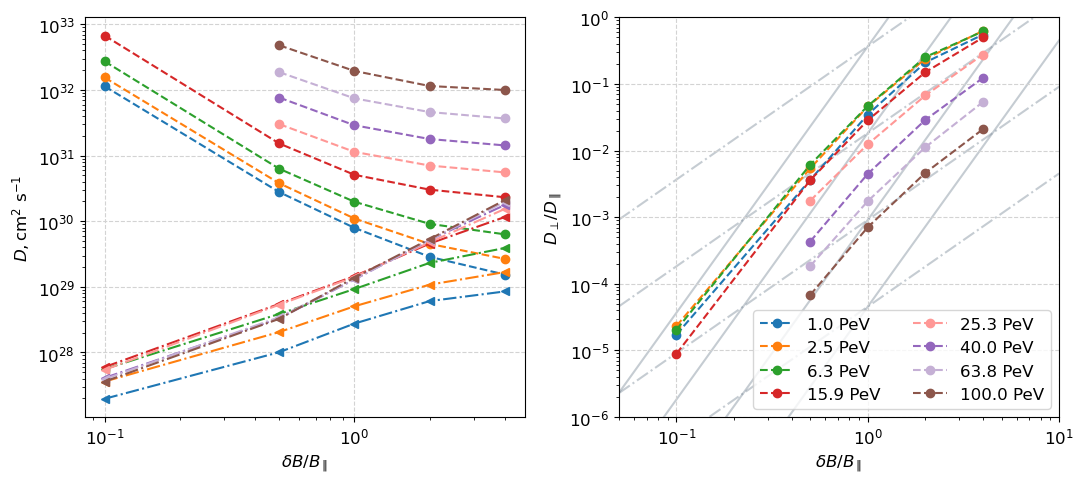

In [223]:
set_plotting_defaults()
plt.figure(figsize=(11, 5))
plt.subplot(1, 2, 1)
for j in range(len(e)):
    if j < 6 and j % 2 != 0:
        continue
    plt.errorbar(etas, d_prl[:, j], color=Tab20[j], linestyle='dashed', marker='o')
    plt.errorbar(etas, d_perp[:, j], color=Tab20[j], linestyle='dashdot', marker='<')
plt.xscale('log')
plt.xlabel(r"$\delta B/B_\parallel$")
plt.yscale('log')
plt.ylabel(r"$D, \mathrm{cm^2~s^{-1}}$")

plt.subplot(1, 2, 2)
for j in range(len(e)):
    if j < 6 and j % 2 != 0:
        continue
    ratio = d_perp[:, j] / d_prl[:, j]
    plt.errorbar(etas[ratio > .0], ratio[ratio > .0],
                 color=Tab20[j], marker='o', linestyle='dashed', label=f"{e[j].to(u.PeV):.1f}")

x = np.linspace(5e-2, 1e1, 100)

for k in range(-10, 0, 3):
    plt.plot(x, np.exp(k) * x**4, color='slategray', alpha=.4, zorder=0, linestyle='solid')
    plt.plot(x, np.exp(k) * x**2, color='slategray', alpha=.4, zorder=0, linestyle='dashdot')

plt.xscale('log')
plt.xlabel(r"$\delta B/B_\parallel$")
plt.yscale('log')
plt.ylabel(r"$D_\perp / D_\parallel$")
plt.xlim(5e-2, 1e1)
plt.ylim(1e-6, 1e0)

plt.legend(ncols=2)

plt.tight_layout()
plt.show()

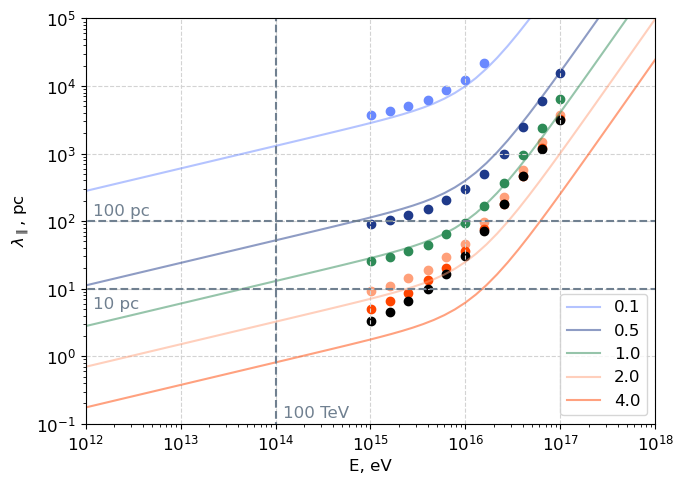

In [224]:
for i in range(len(etas)):
    plt.scatter(e, (3 * d[i, :] / cst.c).to(u.pc), color=colors[i])

for i, bfr in enumerate(etas[:-1]):
    gyr_radii = gyration_radius(e_line, bfield / np.sqrt(1 + bfr**2))
    plt.loglog(e_line, (3 * 2.5 * dif_cof(10 * u.pc, bfr, gyr_radii) / cst.c).to(u.pc), label=f"{bfr}",
               color=colors[i], linestyle='-', alpha=0.5)

plt.vlines([1e14], 1e-2, 1e6, color='slategray', linestyle='dashed')
plt.text(1.2e14, 1.2e-1, "100 TeV", color='slategray')

plt.hlines([1e1, 1e2], 1e9, 1e20, color='slategray', linestyle='dashed')
plt.text(1.2e12, 1.2e2, "100 pc", color='slategray')
plt.text(1.2e12, 0.5e1, "10 pc", color='slategray')

plt.xscale('log')
plt.xlabel(r"E, eV")
plt.yscale('log')
plt.ylabel(r"$\lambda_\parallel$, pc")
plt.xlim(1e12, 1e18)
plt.ylim(1e-1, 1e5)

plt.legend(ncol=1, loc=4)

plt.tight_layout()
save_figure("dif_length")
plt.show()